# 26. Model Comparison — v0 (mushroom.pt) vs v1 (retrained)

Empirically choose the counting model on a leakage-free validation set.


## Why and how

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

**Question.** Which detector should count scale worms — v0 (`mushroom.pt`, original
lab model) or v1 (`best.pt`, retrained)? The v0 pilot returned 68% zero-detection on
Feb-2024 scene1 frames; that could be genuine low abundance *or* v0 recall failure.
This notebook decides it empirically instead of by intuition.

**Design.** Both models run on the **identical** full-resolution frames — one per
scene1 recording, extracted once at `scene1_time_s` — so any count difference is the
model, not the input. Each model's counts are then compared (a) to each other and
(b) to a **hand count** made by eye on the same frames (ground truth).

**Validation set.** Feb 2024 scene1 frames (n=31). This is **leakage-free for v1**:
v1 was fine-tuned only on Oct-2024 frames, so Feb 2024 is unseen by it. (For a larger
set, add more leakage-free months — any month except the v1 training footage.)

**Metrics (per model, vs hand count):** mean absolute error (MAE) with a bootstrap
95% CI, mean signed error (bias: + = over-count), RMSE, and exact-count-match rate.
Reporting a CI, not just a point estimate, follows the lab's defensible-statistics rule.

**Hand-count protocol.** Cell 3 writes a template CSV and saves the frames as PNGs.
Open each frame (e.g. `plt.imshow`), count the scale worms you can identify, and enter
the number in the `human_count` column. Save the CSV, then run Cells 5–6. Existing
entries are never overwritten.

**Caveats.** (1) `scene1_time_s` is ~30 s precise, so the frame may sit slightly off the
best view. (2) A model chosen here still needs the IRR κ gate and, ideally, comparison
against v2 once retrained before feeding thesis conclusions.

</span>


In [1]:
import csv
import json
import subprocess
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from count_frames import count_worms, extract_frame, parse_stem_dt, stem_to_video

from ultralytics import YOLO

# ── Configuration ─────────────────────────────────────────────
MODELS = {
    "v0_mushroom": Path("../mushroom.pt"),
    "v1_retrained": Path("runs/detect/verification_session/runs/scaleworm_retrained_v1/weights/best.pt"),
}
SORT_LOG = Path("../scene_sorting/full_2023_2024/sort_log.csv")
VIDEO_ROOT = Path("/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301")
VALIDATION_MONTH = "2024/02"       # leakage-free for v1 (trained on Oct 2024)
CONF_THRESHOLD = 0.25

FRAMES_DIR = Path("./model_comparison_frames")      # saved PNGs (shared inputs)
HANDCOUNT_CSV = Path("./model_comparison_handcount.csv")
RESULTS_CSV = Path("./model_comparison_results.csv")
# ────────────────────────────────────────────────────

FRAMES_DIR.mkdir(exist_ok=True)
for name, p in MODELS.items():
    print(f"{name:14s} exists={p.exists()}  {p}")


v0_mushroom    exists=True  ../mushroom.pt
v1_retrained   exists=True  runs/detect/verification_session/runs/scaleworm_retrained_v1/weights/best.pt


In [2]:
# Build the scene list and extract ONE full-res frame per scene1 recording (once).
month_tag = "-" + VALIDATION_MONTH.replace("/", "")
scenes = []
with SORT_LOG.open() as fh:
    for row in csv.DictReader(fh):
        if row["decision"] != "scene1" or month_tag not in row["stem"]:
            continue
        scenes.append((row["stem"], float(row["scene1_time_s"]),
                       stem_to_video(row["stem"], VIDEO_ROOT)))
scenes.sort(key=lambda s: s[0])
print(f"scene1 validation frames ({VALIDATION_MONTH}): {len(scenes)}")

for stem, t_s, vp in scenes:
    out = FRAMES_DIR / f"{stem}.png"
    if out.exists():
        continue
    ok = vp.exists() and extract_frame(vp, t_s, out)
    if not ok:
        print(f"  FAILED to extract {stem} (video_exists={vp.exists()})")
print(f"frames on disk: {len(list(FRAMES_DIR.glob('*.png')))}")

# Write a hand-count template WITHOUT clobbering any counts already entered.
existing = {}
if HANDCOUNT_CSV.exists():
    with HANDCOUNT_CSV.open() as fh:
        for row in csv.DictReader(fh):
            existing[row["stem"]] = row.get("human_count", "")
with HANDCOUNT_CSV.open("w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["stem", "dt", "scene1_time_s", "human_count"])
    for stem, t_s, _ in scenes:
        w.writerow([stem, parse_stem_dt(stem).isoformat(), t_s, existing.get(stem, "")])
n_filled = sum(1 for v in existing.values() if str(v).strip() != "")
print(f"hand-count template: {HANDCOUNT_CSV}  ({n_filled} of {len(scenes)} counts filled)")
print("-> Open each PNG in model_comparison_frames/, count worms, fill human_count, save.")


scene1 validation frames (2024/02): 31
frames on disk: 31
hand-count template: model_comparison_handcount.csv  (0 of 31 counts filled)
-> Open each PNG in model_comparison_frames/, count worms, fill human_count, save.


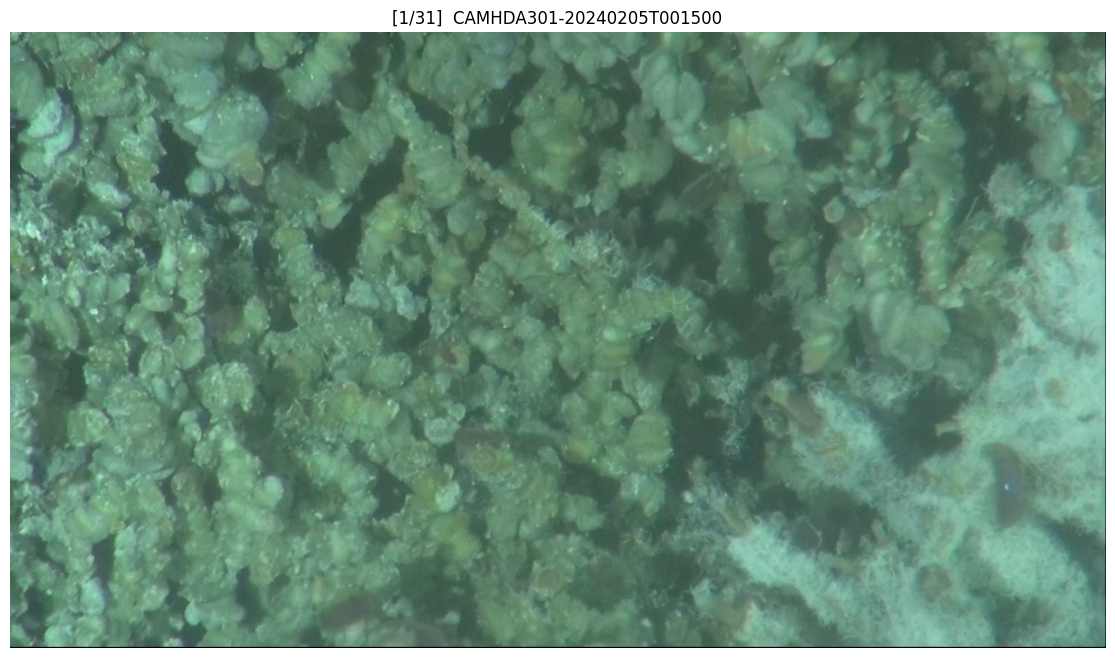

saved  human_count = 17  for CAMHDA301-20240205T001500
progress: 31/31 frames counted
-> next: set IDX = 1, MY_COUNT = <count for that frame>


In [37]:
# ── Hand-count viewer + recorder — ONE frame at a time ──
# HOW TO USE:
#   1. Set IDX to the frame you want to see. Leave MY_COUNT = None to just LOOK.
#   2. Once you've counted the worms, set MY_COUNT = <your number> and Shift+Enter:
#      it writes that number to the right row of the hand-count CSV for you.
#   3. Bump IDX, set MY_COUNT back to your next count, repeat.
#   Re-running a frame with a new number overwrites it — safe for fixing mistakes.
#
# Shows NO model counts on purpose: the hand count must stay independent of the models.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

IDX = 0            # <-- which frame: 0 .. 30
MY_COUNT = 17    # <-- None = view only;  a number = record THIS frame's worm count

frames = sorted(FRAMES_DIR.glob("*.png"))
f = frames[IDX]
stem = f.stem

fig, ax = plt.subplots(figsize=(15, 8))
ax.imshow(mpimg.imread(f))
ax.set_axis_off()
ax.set_title(f"[{IDX + 1}/{len(frames)}]  {stem}", fontsize=12)
plt.show()

# read every row, optionally record MY_COUNT into the matching stem, write back
with HANDCOUNT_CSV.open() as fh:
    reader = csv.DictReader(fh)
    fields = list(reader.fieldnames)
    rows = list(reader)

if MY_COUNT is not None:
    matched = False
    for r in rows:
        if r["stem"] == stem:
            r["human_count"] = MY_COUNT
            matched = True
    if matched:
        with HANDCOUNT_CSV.open("w", newline="") as fh:
            w = csv.DictWriter(fh, fieldnames=fields)
            w.writeheader()
            w.writerows(rows)
        print(f"saved  human_count = {MY_COUNT}  for {stem}")
    else:
        print(f"!! no CSV row matches {stem} — nothing written")

filled = sum(1 for r in rows if str(r.get("human_count", "")).strip())
print(f"progress: {filled}/{len(frames)} frames counted")
if MY_COUNT is not None and IDX + 1 < len(frames):
    print(f"-> next: set IDX = {IDX + 1}, MY_COUNT = <count for that frame>")


In [38]:
# Run every model over the identical saved frames -> tidy results CSV (cache-aware).
def load_results():
    if not RESULTS_CSV.exists():
        return {}
    out = {}
    with RESULTS_CSV.open() as fh:
        for row in csv.DictReader(fh):
            out[(row["stem"], row["model"])] = int(row["count"])
    return out


frames = sorted(FRAMES_DIR.glob("*.png"))
results = load_results()
for name, mpath in MODELS.items():
    todo = [f for f in frames if (f.stem, name) not in results]
    if not todo:
        print(f"{name}: all {len(frames)} frames cached")
        continue
    print(f"{name}: scoring {len(todo)} frames ...", flush=True)
    model = YOLO(str(mpath))
    for f in todo:
        preds = model.predict(str(f), conf=CONF_THRESHOLD, verbose=False)
        results[(f.stem, name)] = count_worms([int(b.cls) for b in preds[0].boxes], model.names)

with RESULTS_CSV.open("w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["stem", "model", "count"])
    for (stem, name), c in sorted(results.items()):
        w.writerow([stem, name, c])
print(f"wrote {RESULTS_CSV} ({len(results)} rows)")


v0_mushroom: all 31 frames cached
v1_retrained: all 31 frames cached
wrote model_comparison_results.csv (62 rows)


In [39]:
try:
    import plotly.graph_objects as go
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "plotly"], check=True)
    import plotly.graph_objects as go

# Pivot results: stem -> {model: count}
by_stem = {}
with RESULTS_CSV.open() as fh:
    for row in csv.DictReader(fh):
        by_stem.setdefault(row["stem"], {})[row["model"]] = int(row["count"])
stems = sorted(by_stem)
model_names = list(MODELS)

print("Per-model totals over", len(stems), "scene1 frames:")
for name in model_names:
    vals = [by_stem[s].get(name, 0) for s in stems]
    zeros = sum(1 for v in vals if v == 0)
    print(f"  {name:14s} total={sum(vals):4d}  mean={sum(vals)/len(vals):.2f}  "
          f"max={max(vals)}  zero-detection={zeros}/{len(vals)}")

if len(model_names) == 2:
    a, b = model_names
    diffs = [(s, by_stem[s].get(a, 0), by_stem[s].get(b, 0)) for s in stems]
    disagree = [d for d in diffs if d[1] != d[2]]
    print(f"\n{a} vs {b}: agree on {len(diffs) - len(disagree)}/{len(diffs)} frames; "
          f"differ on {len(disagree)}")
    for s, ca, cb in disagree:
        print(f"    {s}  {a}={ca}  {b}={cb}  (delta {cb - ca:+d})")

fig = go.Figure()
palette = ["#0072B2", "#E69F00", "#009E73"]  # Okabe-Ito
for i, name in enumerate(model_names):
    fig.add_trace(go.Bar(x=stems, y=[by_stem[s].get(name, 0) for s in stems],
                         name=name, marker_color=palette[i % len(palette)]))
fig.update_layout(
    title=f"Per-scene worm count by model — {VALIDATION_MONTH}",
    xaxis_title="scene1 recording", yaxis_title="count (single frame)",
    barmode="group", template="plotly_white", height=480,
)
fig.update_xaxes(tickangle=-60)
fig.show()


Per-model totals over 31 scene1 frames:
  v0_mushroom    total=  16  mean=0.52  max=3  zero-detection=21/31
  v1_retrained   total=  39  mean=1.26  max=4  zero-detection=9/31

v0_mushroom vs v1_retrained: agree on 13/31 frames; differ on 18
    CAMHDA301-20240205T031500  v0_mushroom=0  v1_retrained=1  (delta +1)
    CAMHDA301-20240205T091500  v0_mushroom=0  v1_retrained=1  (delta +1)
    CAMHDA301-20240205T121500  v0_mushroom=0  v1_retrained=1  (delta +1)
    CAMHDA301-20240205T181500  v0_mushroom=0  v1_retrained=1  (delta +1)
    CAMHDA301-20240205T211500  v0_mushroom=2  v1_retrained=1  (delta -1)
    CAMHDA301-20240212T001500  v0_mushroom=0  v1_retrained=1  (delta +1)
    CAMHDA301-20240212T181500  v0_mushroom=1  v1_retrained=2  (delta +1)
    CAMHDA301-20240212T211500  v0_mushroom=0  v1_retrained=1  (delta +1)
    CAMHDA301-20240219T001500  v0_mushroom=0  v1_retrained=2  (delta +2)
    CAMHDA301-20240219T031500  v0_mushroom=0  v1_retrained=2  (delta +2)
    CAMHDA301-20240219T061500

In [40]:
import numpy as np

# Load hand counts (ground truth). Requires human_count filled in Cell 3's CSV.
truth = {}
with HANDCOUNT_CSV.open() as fh:
    for row in csv.DictReader(fh):
        v = str(row.get("human_count", "")).strip()
        if v != "":
            truth[row["stem"]] = int(v)

if not truth:
    print("No hand counts yet. Fill 'human_count' in", HANDCOUNT_CSV, "then re-run this cell.")
else:
    preds = {}
    with RESULTS_CSV.open() as fh:
        for row in csv.DictReader(fh):
            preds.setdefault(row["model"], {})[row["stem"]] = int(row["count"])

    rng = np.random.default_rng(20260826)  # fixed seed: reproducible bootstrap

    def bootstrap_mae(errs, n=2000):
        errs = np.asarray(errs, dtype=float)
        boot = [np.abs(rng.choice(errs, size=len(errs), replace=True)).mean() for _ in range(n)]
        return np.percentile(boot, [2.5, 97.5])

    print(f"Ground-truth frames hand-counted: {len(truth)}\n")
    print(f"{'model':14s} {'MAE':>6} {'95% CI':>16} {'bias':>7} {'RMSE':>6} {'exact':>7}")
    fig_scatter = []
    for name in MODELS:
        common = [s for s in truth if s in preds.get(name, {})]
        errs = [preds[name][s] - truth[s] for s in common]  # signed: + = over-count
        mae = float(np.mean(np.abs(errs)))
        lo, hi = bootstrap_mae(errs)
        bias = float(np.mean(errs))
        rmse = float(np.sqrt(np.mean(np.square(errs))))
        exact = sum(1 for e in errs if e == 0) / len(errs)
        print(f"{name:14s} {mae:6.2f} [{lo:5.2f}, {hi:5.2f}] {bias:+7.2f} {rmse:6.2f} {exact:6.0%}")
        fig_scatter.append((name, [truth[s] for s in common], [preds[name][s] for s in common]))

    try:
        import plotly.graph_objects as go
    except ImportError:
        import plotly.graph_objects as go
    fig = go.Figure()
    palette = ["#0072B2", "#E69F00", "#009E73"]
    hi = max([max(y) for _, x, y in fig_scatter] + [max(x) for _, x, y in fig_scatter] + [1])
    fig.add_trace(go.Scatter(x=[0, hi], y=[0, hi], mode="lines",
                             line=dict(dash="dash", color="grey"), name="y = x (perfect)"))
    for i, (name, x, y) in enumerate(fig_scatter):
        fig.add_trace(go.Scatter(x=x, y=y, mode="markers", name=name,
                                 marker=dict(size=10, color=palette[i % len(palette)])))
    fig.update_layout(title=f"Model count vs hand count — {VALIDATION_MONTH}",
                      xaxis_title="hand count (truth)", yaxis_title="model count",
                      template="plotly_white", height=520)
    fig.show()


Ground-truth frames hand-counted: 31

model             MAE           95% CI    bias   RMSE   exact
v0_mushroom      9.23 [ 7.81, 10.71]   -9.23  10.12     0%
v1_retrained     8.48 [ 6.97, 10.03]   -8.48   9.49     0%
